# AS7263 Fresh-Orange Data Preparation and Exploration

This notebook prepares AS7263 near-infrared sensor readings collected from fresh oranges.

## Objectives

1. Load and inspect the dataset.
2. Validate column names and data types.
3. Check missing, invalid, and impossible values.
4. detect and remove exact duplicate spectra.
5. Explore distributions using summary statistics and graphs.
6. Detect potential outliers using the IQR method and robust z-scores.
7. Avoid blindly deleting unusual readings.
8. Export prepared datasets for later integration with spoiled-orange data.
9. Create a reusable preprocessing structure for future classification.

> **Important:** This dataset contains only fresh-orange readings. It can be cleaned and explored now, but a fresh-versus-spoiled classifier cannot be trained until spoiled-orange observations are added.


## 1. Import libraries

The notebook uses:

- `pandas` for table operations.
- `numpy` for numerical calculations.
- `matplotlib` for visualization.
- `pathlib` for reliable file paths.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42


## 2. File configuration

Keep the CSV file in the same folder as this notebook. Change `DATA_FILE` only when the filename or location changes.


In [2]:
DATA_FILE = Path("fresh_orange_AS7263_readings.csv")

if not DATA_FILE.exists():
    # This fallback helps when running the notebook from another directory.
    DATA_FILE = Path("/mnt/data/fresh_orange_AS7263_readings.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "The fresh-orange CSV file was not found. "
        "Place it beside this notebook or update DATA_FILE."
    )

print("Using file:", DATA_FILE.resolve())


Using file: /mnt/data/fresh_orange_AS7263_readings.csv


## 3. Load the dataset

In [3]:
raw_df = pd.read_csv(DATA_FILE)

print("Dataset shape:", raw_df.shape)
display(raw_df.head(10))


Dataset shape: (74, 8)


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label
0,1,26.180,5.100,5.210,3.430,2.670,1.210,Fresh
1,2,9.110,2.040,1.740,1.710,0.890,0.000,Fresh
2,3,26.180,5.100,5.210,3.430,2.670,1.210,Fresh
3,4,29.590,5.100,6.080,3.430,2.670,1.210,Fresh
4,5,36.420,7.140,6.080,3.430,2.670,1.210,Fresh
5,6,2.280,2.040,0.870,0.000,0.890,0.000,Fresh
6,7,2.280,1.020,0.870,0.000,0.000,0.000,Fresh
7,8,35.280,8.160,4.350,2.570,2.670,1.210,Fresh
8,9,31.870,8.160,3.480,2.570,2.670,1.210,Fresh
9,10,35.280,8.160,4.350,2.570,2.670,1.210,Fresh


## 4. Define the expected structure

The six wavelength columns are the model input features. `sample_id` is an identifier, not a sensor feature. `label` identifies the orange condition.


In [4]:
wavelength_columns = [
    "610_nm",
    "680_nm",
    "730_nm",
    "760_nm",
    "810_nm",
    "860_nm",
]

expected_columns = ["sample_id", *wavelength_columns, "label"]

missing_columns = sorted(set(expected_columns) - set(raw_df.columns))
unexpected_columns = sorted(set(raw_df.columns) - set(expected_columns))

print("Missing expected columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")


Missing expected columns: []
Unexpected columns: []


## 5. Initial structural inspection

In [5]:
print("Rows and columns:", raw_df.shape)
print("\nColumn data types:")
display(raw_df.dtypes.to_frame("dtype"))

print("\nGeneral information:")
raw_df.info()


Rows and columns: (74, 8)

Column data types:


,dtype
sample_id,int64
610_nm,float64
680_nm,float64
730_nm,float64
760_nm,float64
810_nm,float64
860_nm,float64
label,object



General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  74 non-null     int64  
 1   610_nm     74 non-null     float64
 2   680_nm     74 non-null     float64
 3   730_nm     74 non-null     float64
 4   760_nm     74 non-null     float64
 5   810_nm     74 non-null     float64
 6   860_nm     74 non-null     float64
 7   label      74 non-null     object 
dtypes: float64(6), int64(1), object(1)
memory usage: 4.8+ KB


## 6. Standardize and validate data types

In [6]:
df = raw_df.copy()

# Remove leading and trailing spaces from column names.
df.columns = df.columns.str.strip()

# Convert sensor columns to numeric. Invalid text becomes NaN for inspection.
for column in wavelength_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Clean labels.
df["label"] = df["label"].astype(str).str.strip().str.title()

# Create a numeric label now for future integration:
# Fresh = 1, Spoiled = 0.
label_map = {"Fresh": 1, "Spoiled": 0}
df["label_numeric"] = df["label"].map(label_map)

display(df.head())


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric
0,1,26.180,5.100,5.210,3.430,2.670,1.210,Fresh,1
1,2,9.110,2.040,1.740,1.710,0.890,0.000,Fresh,1
2,3,26.180,5.100,5.210,3.430,2.670,1.210,Fresh,1
3,4,29.590,5.100,6.080,3.430,2.670,1.210,Fresh,1
4,5,36.420,7.140,6.080,3.430,2.670,1.210,Fresh,1


## 7. Missing-value analysis

Missing readings may result from parsing errors, incomplete serial transmission, communication failure, or manual editing.


In [7]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent,
})

display(missing_summary)

rows_with_missing_values = df[df.isna().any(axis=1)]
print("Rows containing at least one missing value:", len(rows_with_missing_values))
display(rows_with_missing_values)


,missing_count,missing_percent
sample_id,0,0.000
610_nm,0,0.000
680_nm,0,0.000
730_nm,0,0.000
760_nm,0,0.000
810_nm,0,0.000
860_nm,0,0.000
label,0,0.000
label_numeric,0,0.000


Rows containing at least one missing value: 0


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric


### Missing-value cleaning decision

For this sensor dataset, rows missing any wavelength value should normally be removed because all six wavelengths are required by the final classifier. Imputing a missing sensor channel could create an artificial spectrum.

The original row count is preserved in the audit report.


In [8]:
rows_before_missing_removal = len(df)

df = df.dropna(subset=wavelength_columns + ["label_numeric"]).copy()

rows_removed_for_missing_values = rows_before_missing_removal - len(df)

print("Rows removed because of missing values or invalid labels:",
      rows_removed_for_missing_values)
print("Rows remaining:", len(df))


Rows removed because of missing values or invalid labels: 0
Rows remaining: 74


## 8. Range and validity checks

AS7263 calibrated values should not be negative. Zero can be a real low response, but frequent zeros may also indicate weak illumination, insufficient integration time, low gain, sensor movement, or communication issues.


In [9]:
negative_mask = (df[wavelength_columns] < 0).any(axis=1)
negative_rows = df[negative_mask]

print("Rows containing negative sensor values:", len(negative_rows))
display(negative_rows)

zero_counts = (df[wavelength_columns] == 0).sum()
zero_percent = ((df[wavelength_columns] == 0).mean() * 100).round(2)

zero_summary = pd.DataFrame({
    "zero_count": zero_counts,
    "zero_percent": zero_percent,
})

print("\nZero-value summary:")
display(zero_summary)


Rows containing negative sensor values: 0


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric



Zero-value summary:


,zero_count,zero_percent
610_nm,0,0.000
680_nm,3,4.050
730_nm,0,0.000
760_nm,3,4.050
810_nm,12,16.220
860_nm,24,32.430


In [10]:
# Remove physically invalid negative readings.
rows_before_negative_removal = len(df)
df = df.loc[~negative_mask].copy()
rows_removed_for_negative_values = rows_before_negative_removal - len(df)

print("Negative-value rows removed:", rows_removed_for_negative_values)


Negative-value rows removed: 0


## 9. Exact duplicate detection

A duplicate is checked using the six wavelengths and label, not `sample_id`.

Repeated spectra can occur because:

1. The same serial reading was copied twice.
2. The sensor produces quantized values that genuinely repeat.
3. Consecutive samples are stable and identical.

For model development, exact duplicate spectra may make a frequently repeated measurement influence the model too strongly. This notebook removes exact duplicates but preserves the first occurrence.


In [11]:
duplicate_subset = wavelength_columns + ["label"]

duplicate_mask = df.duplicated(subset=duplicate_subset, keep=False)
duplicate_rows = df.loc[duplicate_mask].sort_values(duplicate_subset)

print("Rows involved in duplicate groups:", len(duplicate_rows))
print(
    "Additional exact duplicate rows:",
    df.duplicated(subset=duplicate_subset, keep="first").sum(),
)
display(duplicate_rows)


Rows involved in duplicate groups: 10
Additional exact duplicate rows: 5


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric
29,30,7.970,1.020,1.740,0.860,0.000,0.000,Fresh,1
30,31,7.970,1.020,1.740,0.860,0.000,0.000,Fresh,1
0,1,26.180,5.100,5.210,3.430,2.670,1.210,Fresh,1
2,3,26.180,5.100,5.210,3.430,2.670,1.210,Fresh,1
51,52,30.730,8.160,3.480,2.570,2.670,1.210,Fresh,1
53,54,30.730,8.160,3.480,2.570,2.670,1.210,Fresh,1
7,8,35.280,8.160,4.350,2.570,2.670,1.210,Fresh,1
9,10,35.280,8.160,4.350,2.570,2.670,1.210,Fresh,1
44,45,36.420,8.160,4.350,2.570,2.670,1.210,Fresh,1
65,66,36.420,8.160,4.350,2.570,2.670,1.210,Fresh,1


In [12]:
rows_before_duplicate_removal = len(df)

df_deduplicated = (
    df.drop_duplicates(subset=duplicate_subset, keep="first")
      .copy()
      .reset_index(drop=True)
)

rows_removed_as_duplicates = rows_before_duplicate_removal - len(df_deduplicated)

print("Duplicate rows removed:", rows_removed_as_duplicates)
print("Rows after duplicate removal:", len(df_deduplicated))


Duplicate rows removed: 5
Rows after duplicate removal: 69


## 10. Descriptive statistics

In [13]:
descriptive_statistics = df_deduplicated[wavelength_columns].describe().T

descriptive_statistics["median"] = (
    df_deduplicated[wavelength_columns].median()
)
descriptive_statistics["iqr"] = (
    df_deduplicated[wavelength_columns].quantile(0.75)
    - df_deduplicated[wavelength_columns].quantile(0.25)
)
descriptive_statistics["zero_count"] = (
    df_deduplicated[wavelength_columns] == 0
).sum()

display(descriptive_statistics)


,count,mean,std,min,25%,50%,75%,max,median,iqr,zero_count
610_nm,69.000,23.869,15.107,2.280,13.660,22.760,31.870,92.190,22.760,18.210,0
680_nm,69.000,5.560,4.427,0.000,2.040,5.100,8.160,29.600,5.100,6.120,3
730_nm,69.000,3.264,1.621,0.870,2.610,3.480,4.350,8.690,3.480,1.740,0
760_nm,69.000,2.135,1.115,0.000,1.710,2.570,2.570,5.990,2.570,0.860,3
810_nm,69.000,1.793,1.334,0.000,0.890,1.780,2.670,8.000,1.780,1.780,11
860_nm,69.000,0.859,0.690,0.000,0.000,1.210,1.210,3.620,1.210,1.210,23


## 11. Distribution visualization

Histograms show the shape, concentration, skewness, and possible multiple measurement groups in each wavelength.


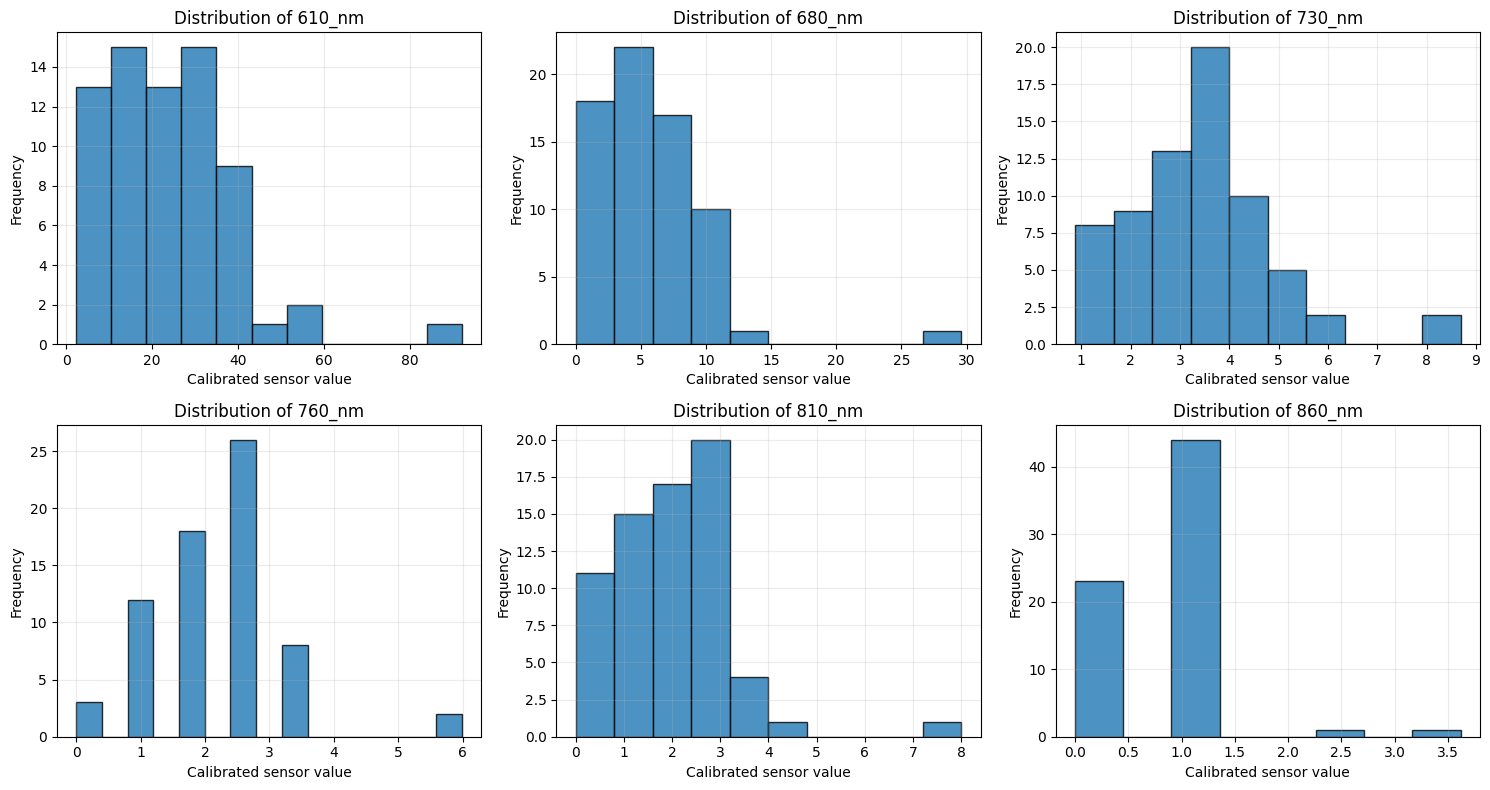

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for axis, column in zip(axes, wavelength_columns):
    axis.hist(
        df_deduplicated[column],
        bins="auto",
        edgecolor="black",
        alpha=0.8,
    )
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel("Calibrated sensor value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 12. Boxplots for potential outliers

A boxplot flags observations beyond 1.5 times the interquartile range. A flagged reading is not automatically an error. It may represent a valid orange surface, a change in distance, illumination variation, or a genuine sensor anomaly.


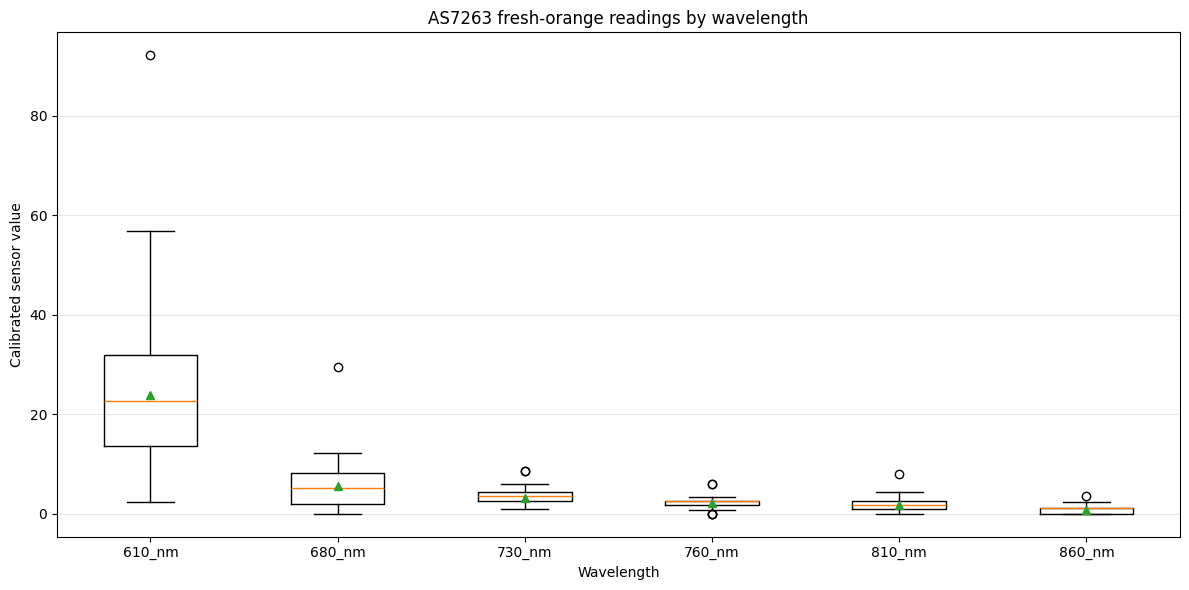

In [15]:
plt.figure(figsize=(12, 6))
plt.boxplot(
    [df_deduplicated[column] for column in wavelength_columns],
    tick_labels=wavelength_columns,
    showmeans=True,
)
plt.title("AS7263 fresh-orange readings by wavelength")
plt.xlabel("Wavelength")
plt.ylabel("Calibrated sensor value")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Because the 610 nm values are much larger than several other wavelengths, standardized boxplots are also useful. They place each wavelength on a comparable scale without changing the original exported measurements.


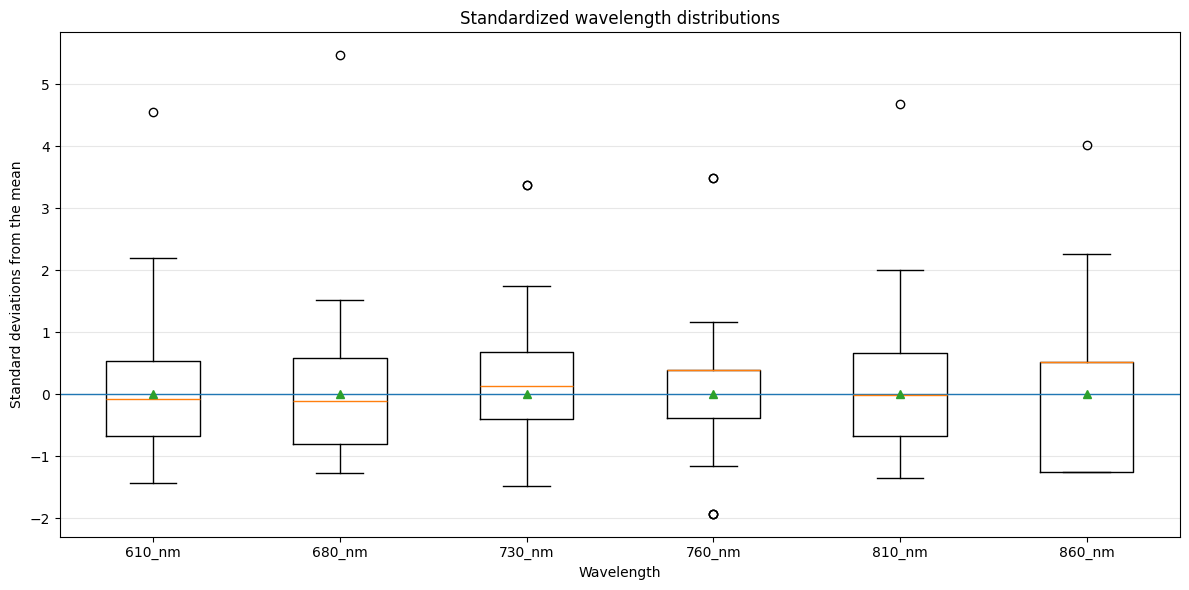

In [16]:
standardized = (
    df_deduplicated[wavelength_columns]
    - df_deduplicated[wavelength_columns].mean()
) / df_deduplicated[wavelength_columns].std(ddof=0)

plt.figure(figsize=(12, 6))
plt.boxplot(
    [standardized[column] for column in wavelength_columns],
    tick_labels=wavelength_columns,
    showmeans=True,
)
plt.axhline(0, linewidth=1)
plt.title("Standardized wavelength distributions")
plt.xlabel("Wavelength")
plt.ylabel("Standard deviations from the mean")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Spectral profile visualization

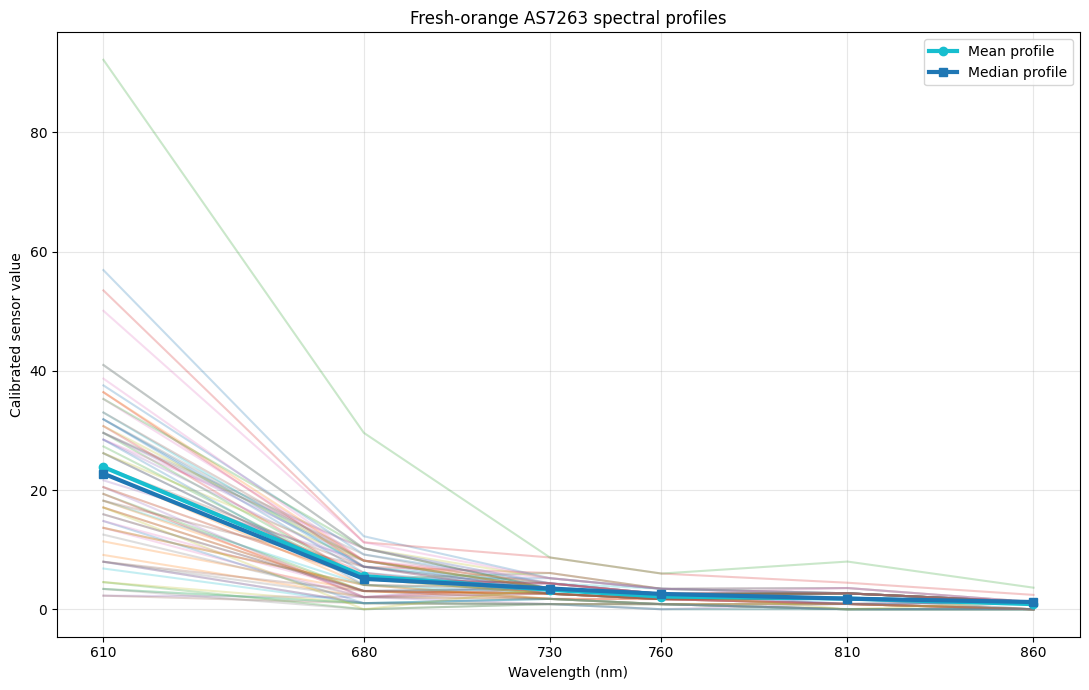

In [17]:
wavelength_numbers = np.array([610, 680, 730, 760, 810, 860])

plt.figure(figsize=(11, 7))

for _, row in df_deduplicated.iterrows():
    plt.plot(
        wavelength_numbers,
        row[wavelength_columns].to_numpy(dtype=float),
        alpha=0.25,
    )

mean_profile = (
    df_deduplicated[wavelength_columns]
    .mean()
    .to_numpy(dtype=float)
)
median_profile = (
    df_deduplicated[wavelength_columns]
    .median()
    .to_numpy(dtype=float)
)

plt.plot(
    wavelength_numbers,
    mean_profile,
    marker="o",
    linewidth=3,
    label="Mean profile",
)
plt.plot(
    wavelength_numbers,
    median_profile,
    marker="s",
    linewidth=3,
    label="Median profile",
)

plt.title("Fresh-orange AS7263 spectral profiles")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Calibrated sensor value")
plt.xticks(wavelength_numbers)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 14. Correlation analysis

Correlation indicates whether wavelength channels tend to rise and fall together. Strong correlation is common in spectral data because illumination intensity, distance, and surface reflectance can influence several channels simultaneously.

Correlation does not prove that one wavelength causes another.


,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm
610_nm,1.000,0.928,0.883,0.893,0.938,0.832
680_nm,0.928,1.000,0.743,0.767,0.932,0.812
730_nm,0.883,0.743,1.000,0.959,0.853,0.773
760_nm,0.893,0.767,0.959,1.000,0.855,0.807
810_nm,0.938,0.932,0.853,0.855,1.000,0.828
860_nm,0.832,0.812,0.773,0.807,0.828,1.000


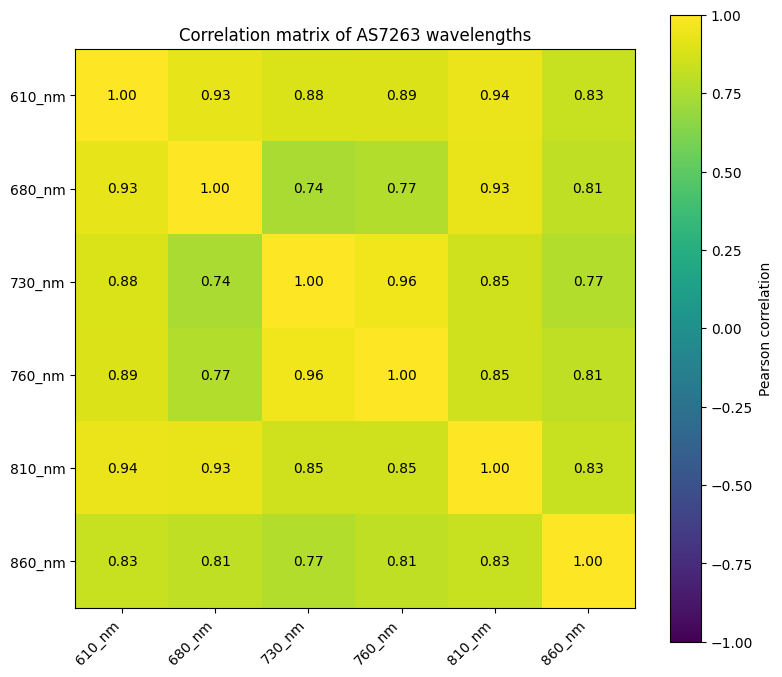

In [18]:
correlation_matrix = df_deduplicated[wavelength_columns].corr()

display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1)

ax.set_xticks(range(len(wavelength_columns)))
ax.set_yticks(range(len(wavelength_columns)))
ax.set_xticklabels(wavelength_columns, rotation=45, ha="right")
ax.set_yticklabels(wavelength_columns)

for i in range(len(wavelength_columns)):
    for j in range(len(wavelength_columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix of AS7263 wavelengths")
plt.tight_layout()
plt.show()


## 15. Pairwise scatterplots

These plots help identify nonlinear relationships, clusters, unusual readings, and changes caused by illumination or sensor positioning.


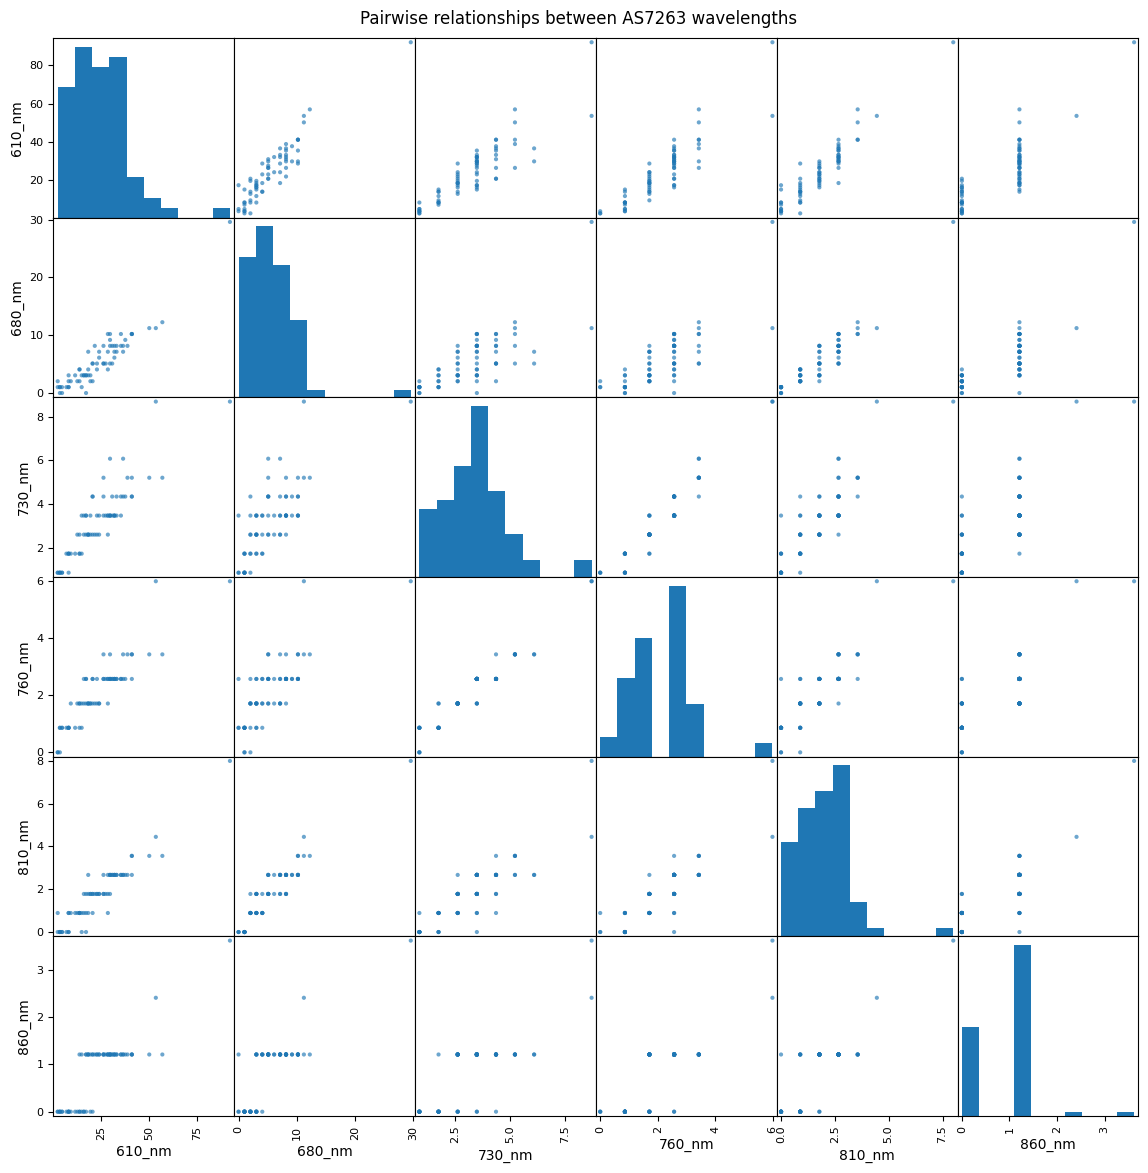

In [19]:
pd.plotting.scatter_matrix(
    df_deduplicated[wavelength_columns],
    figsize=(14, 14),
    diagonal="hist",
    alpha=0.65,
)
plt.suptitle(
    "Pairwise relationships between AS7263 wavelengths",
    y=0.90,
)
plt.show()


## 16. IQR outlier detection

For every wavelength:

- Lower limit = Q1 − 1.5 × IQR
- Upper limit = Q3 + 1.5 × IQR

A row is flagged when at least one channel lies beyond its limits.


In [20]:
q1 = df_deduplicated[wavelength_columns].quantile(0.25)
q3 = df_deduplicated[wavelength_columns].quantile(0.75)
iqr = q3 - q1

iqr_lower_limits = q1 - 1.5 * iqr
iqr_upper_limits = q3 + 1.5 * iqr

iqr_limits = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "lower_limit": iqr_lower_limits,
    "upper_limit": iqr_upper_limits,
})

display(iqr_limits)


,Q1,Q3,IQR,lower_limit,upper_limit
610_nm,13.660,31.870,18.210,-13.655,59.185
680_nm,2.040,8.160,6.120,-7.140,17.340
730_nm,2.610,4.350,1.740,0.000,6.960
760_nm,1.710,2.570,0.860,0.420,3.860
810_nm,0.890,2.670,1.780,-1.780,5.340
860_nm,0.000,1.210,1.210,-1.815,3.025


In [21]:
iqr_channel_flags = (
    (df_deduplicated[wavelength_columns] < iqr_lower_limits)
    | (df_deduplicated[wavelength_columns] > iqr_upper_limits)
)

df_flagged = df_deduplicated.copy()
df_flagged["iqr_outlier_count"] = iqr_channel_flags.sum(axis=1)
df_flagged["iqr_outlier"] = df_flagged["iqr_outlier_count"] > 0

print("Rows flagged by IQR:", int(df_flagged["iqr_outlier"].sum()))
display(
    df_flagged.loc[df_flagged["iqr_outlier"]]
    .sort_values("iqr_outlier_count", ascending=False)
)


Rows flagged by IQR: 5


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric,iqr_outlier_count,iqr_outlier
52,57,92.190,29.600,8.690,5.990,8.000,3.620,Fresh,1,6,True
43,47,53.500,11.230,8.690,5.990,4.450,2.410,Fresh,1,2,True
4,6,2.280,2.040,0.870,0.000,0.890,0.000,Fresh,1,1,True
29,33,3.410,1.020,0.870,0.000,0.000,0.000,Fresh,1,1,True
5,7,2.280,1.020,0.870,0.000,0.000,0.000,Fresh,1,1,True


## 17. Robust z-score outlier detection

A robust z-score uses the median and median absolute deviation (MAD), making it less sensitive to extreme observations than an ordinary z-score.

The common threshold `|robust z| > 3.5` is used for flagging.


In [22]:
median_values = df_deduplicated[wavelength_columns].median()
absolute_deviation = (
    df_deduplicated[wavelength_columns] - median_values
).abs()
mad_values = absolute_deviation.median()

# Avoid division by zero if a future channel has no variation.
safe_mad = mad_values.replace(0, np.nan)

robust_z = (
    0.6745
    * (df_deduplicated[wavelength_columns] - median_values)
    / safe_mad
)

robust_z_flags = robust_z.abs() > 3.5

df_flagged["robust_z_outlier_count"] = robust_z_flags.sum(axis=1)
df_flagged["robust_z_outlier"] = (
    df_flagged["robust_z_outlier_count"] > 0
)

print(
    "Rows flagged by robust z-score:",
    int(df_flagged["robust_z_outlier"].sum()),
)

display(
    df_flagged.loc[df_flagged["robust_z_outlier"]]
    .sort_values("robust_z_outlier_count", ascending=False)
)


Rows flagged by robust z-score: 2


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric,iqr_outlier_count,iqr_outlier,robust_z_outlier_count,robust_z_outlier
52,57,92.190,29.600,8.690,5.990,8.000,3.620,Fresh,1,6,True,4,True
43,47,53.500,11.230,8.690,5.990,4.450,2.410,Fresh,1,2,True,1,True


## 18. Conservative outlier decision

Do not remove a row merely because one channel crosses an IQR boundary.

This notebook defines a **strong outlier candidate** as a row that:

1. Is flagged by both IQR and robust z-score methods, or
2. Is flagged in three or more wavelength channels by either method.

These rows should be checked against laboratory notes, sensor distance, illumination, gain, integration time, and orange position.

The notebook exports:

- A deduplicated dataset with all valid values retained.
- An outlier-flagged dataset for investigation.
- A conservative cleaned dataset excluding strong candidates.

For formal model training, compare performance with and without the strong candidates before permanently discarding them.


In [23]:
df_flagged["strong_outlier_candidate"] = (
    (
        df_flagged["iqr_outlier"]
        & df_flagged["robust_z_outlier"]
    )
    | (df_flagged["iqr_outlier_count"] >= 3)
    | (df_flagged["robust_z_outlier_count"] >= 3)
)

strong_candidates = df_flagged[
    df_flagged["strong_outlier_candidate"]
].copy()

print("Strong outlier candidates:", len(strong_candidates))
display(strong_candidates)


Strong outlier candidates: 2


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric,iqr_outlier_count,iqr_outlier,robust_z_outlier_count,robust_z_outlier,strong_outlier_candidate
43,47,53.500,11.230,8.690,5.990,4.450,2.410,Fresh,1,2,True,1,True,True
52,57,92.190,29.600,8.690,5.990,8.000,3.620,Fresh,1,6,True,4,True,True


## 19. Compare the mean profile before and after conservative filtering

Large changes indicate that the flagged readings strongly affect the dataset. This comparison helps prevent unjustified deletion.


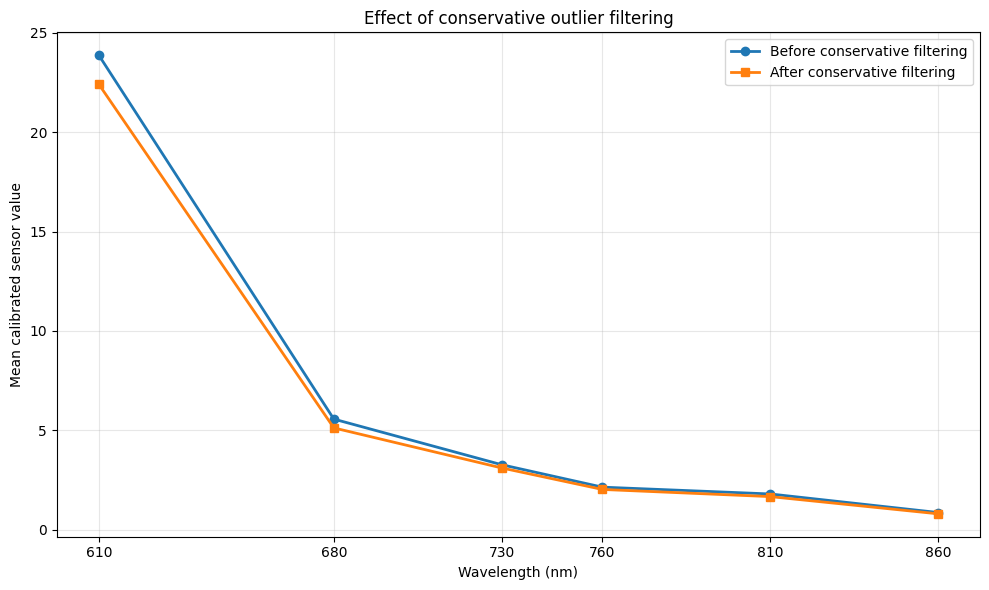

,mean_before,mean_after,absolute_change
610_nm,23.869,22.407,1.462
680_nm,5.560,5.117,0.443
730_nm,3.264,3.102,0.162
760_nm,2.135,2.020,0.115
810_nm,1.793,1.660,0.132
860_nm,0.859,0.795,0.064


In [24]:
conservative_clean_df = df_flagged.loc[
    ~df_flagged["strong_outlier_candidate"]
].copy()

before_mean = (
    df_flagged[wavelength_columns]
    .mean()
    .to_numpy(dtype=float)
)
after_mean = (
    conservative_clean_df[wavelength_columns]
    .mean()
    .to_numpy(dtype=float)
)

plt.figure(figsize=(10, 6))
plt.plot(
    wavelength_numbers,
    before_mean,
    marker="o",
    linewidth=2,
    label="Before conservative filtering",
)
plt.plot(
    wavelength_numbers,
    after_mean,
    marker="s",
    linewidth=2,
    label="After conservative filtering",
)
plt.title("Effect of conservative outlier filtering")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean calibrated sensor value")
plt.xticks(wavelength_numbers)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "mean_before": before_mean,
    "mean_after": after_mean,
    "absolute_change": np.abs(before_mean - after_mean),
}, index=wavelength_columns)

display(comparison)


## 20. Optional signal normalization for future experiments

Raw readings are affected by total signal intensity, sensor distance, illumination, and orange orientation. Shape-based normalization may reduce these effects.

Two possible versions are created for research comparison:

1. **Sum normalization:** each channel is divided by the sum of all six channels.
2. **610 nm ratio normalization:** each channel is divided by the 610 nm reading.

Do not replace the raw data permanently. Keep raw and normalized features so their model performance can be compared after spoiled data are collected.


In [25]:
normalized_df = conservative_clean_df.copy()

row_sum = normalized_df[wavelength_columns].sum(axis=1)
safe_row_sum = row_sum.replace(0, np.nan)

for column in wavelength_columns:
    normalized_df[f"{column}_sum_ratio"] = (
        normalized_df[column] / safe_row_sum
    )

safe_610 = normalized_df["610_nm"].replace(0, np.nan)

for column in wavelength_columns:
    normalized_df[f"{column}_to_610"] = (
        normalized_df[column] / safe_610
    )

display(normalized_df.head())


,sample_id,610_nm,680_nm,730_nm,760_nm,810_nm,860_nm,label,label_numeric,iqr_outlier_count,iqr_outlier,robust_z_outlier_count,robust_z_outlier,strong_outlier_candidate,610_nm_sum_ratio,680_nm_sum_ratio,730_nm_sum_ratio,760_nm_sum_ratio,810_nm_sum_ratio,860_nm_sum_ratio,610_nm_to_610,680_nm_to_610,730_nm_to_610,760_nm_to_610,810_nm_to_610,860_nm_to_610
0,1,26.180,5.100,5.210,3.430,2.670,1.210,Fresh,1,0,False,0,False,False,0.598,0.116,0.119,0.078,0.061,0.028,1.000,0.195,0.199,0.131,0.102,0.046
1,2,9.110,2.040,1.740,1.710,0.890,0.000,Fresh,1,0,False,0,False,False,0.588,0.132,0.112,0.110,0.057,0.000,1.000,0.224,0.191,0.188,0.098,0.000
2,4,29.590,5.100,6.080,3.430,2.670,1.210,Fresh,1,0,False,0,False,False,0.615,0.106,0.126,0.071,0.056,0.025,1.000,0.172,0.205,0.116,0.090,0.041
3,5,36.420,7.140,6.080,3.430,2.670,1.210,Fresh,1,0,False,0,False,False,0.640,0.125,0.107,0.060,0.047,0.021,1.000,0.196,0.167,0.094,0.073,0.033
4,6,2.280,2.040,0.870,0.000,0.890,0.000,Fresh,1,1,True,0,False,False,0.375,0.336,0.143,0.000,0.146,0.000,1.000,0.895,0.382,0.000,0.390,0.000


## 21. Data-quality summary

This creates an audit table documenting every cleaning operation.


In [26]:
quality_summary = pd.DataFrame({
    "metric": [
        "Original rows",
        "Rows removed for missing/invalid values",
        "Rows removed for negative values",
        "Exact duplicate rows removed",
        "Rows after duplicate removal",
        "Rows flagged by IQR",
        "Rows flagged by robust z-score",
        "Strong outlier candidates",
        "Rows in conservative cleaned dataset",
    ],
    "value": [
        len(raw_df),
        rows_removed_for_missing_values,
        rows_removed_for_negative_values,
        rows_removed_as_duplicates,
        len(df_deduplicated),
        int(df_flagged["iqr_outlier"].sum()),
        int(df_flagged["robust_z_outlier"].sum()),
        int(df_flagged["strong_outlier_candidate"].sum()),
        len(conservative_clean_df),
    ],
})

display(quality_summary)


,metric,value
0,Original rows,74
1,Rows removed for missing/invalid values,0
2,Rows removed for negative values,0
3,Exact duplicate rows removed,5
4,Rows after duplicate removal,69
5,Rows flagged by IQR,5
6,Rows flagged by robust z-score,2
7,Strong outlier candidates,2
8,Rows in conservative cleaned dataset,67


## 22. Export prepared datasets

Four files are produced:

1. `fresh_orange_deduplicated.csv` — valid rows after exact duplicate removal.
2. `fresh_orange_outlier_flagged.csv` — includes all outlier flags.
3. `fresh_orange_cleaned_conservative.csv` — excludes strong candidates.
4. `fresh_orange_normalized_features.csv` — includes optional ratio features.
5. `fresh_orange_data_quality_summary.csv` — cleaning audit.


In [27]:
OUTPUT_DIRECTORY = Path("prepared_output")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

deduplicated_export = df_deduplicated.copy()
flagged_export = df_flagged.copy()
clean_export = conservative_clean_df.copy()

# Reassign simple sequential IDs in cleaned exports while preserving original IDs.
for frame in [deduplicated_export, flagged_export, clean_export, normalized_df]:
    frame.insert(0, "prepared_row_id", range(1, len(frame) + 1))

deduplicated_export.to_csv(
    OUTPUT_DIRECTORY / "fresh_orange_deduplicated.csv",
    index=False,
)
flagged_export.to_csv(
    OUTPUT_DIRECTORY / "fresh_orange_outlier_flagged.csv",
    index=False,
)
clean_export.to_csv(
    OUTPUT_DIRECTORY / "fresh_orange_cleaned_conservative.csv",
    index=False,
)
normalized_df.to_csv(
    OUTPUT_DIRECTORY / "fresh_orange_normalized_features.csv",
    index=False,
)
quality_summary.to_csv(
    OUTPUT_DIRECTORY / "fresh_orange_data_quality_summary.csv",
    index=False,
)

print("Files created in:", OUTPUT_DIRECTORY.resolve())
for path in sorted(OUTPUT_DIRECTORY.glob("*.csv")):
    print("-", path.name)


Files created in: /mnt/data/prepared_output
- fresh_orange_cleaned_conservative.csv
- fresh_orange_data_quality_summary.csv
- fresh_orange_deduplicated.csv
- fresh_orange_normalized_features.csv
- fresh_orange_outlier_flagged.csv


## 23. Preparation for spoiled-orange integration

When spoiled data are available:

1. Apply the same column names.
2. Assign `label = "Spoiled"` and `label_numeric = 0`.
3. Apply the same validity checks.
4. Add an `orange_id` identifying the physical fruit.
5. Combine fresh and spoiled datasets.
6. Split training and testing by `orange_id`, not by individual reading.
7. Fit preprocessing only on the training set.
8. Compare logistic regression, a small decision tree, and linear discriminant analysis.
9. Evaluate spoiled-orange recall, confusion matrix, precision, and balanced accuracy.
10. Export the simplest reliable model to the ATmega328P.

### Essential future columns

```text
sample_id
orange_id
610_nm
680_nm
730_nm
760_nm
810_nm
860_nm
label
label_numeric
```

`orange_id` prevents readings from the same physical orange from appearing in both training and test sets, which would give misleadingly high performance.


## 24. Future model-training template

The following cell is intentionally disabled because the present dataset has only one class. Uncomment and adapt it only after fresh and spoiled datasets are combined.


In [28]:
# FUTURE USE ONLY — requires both Fresh and Spoiled classes.
#
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.model_selection import GroupShuffleSplit
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
#
# combined_df = pd.read_csv("combined_fresh_spoiled_oranges.csv")
#
# X = combined_df[wavelength_columns]
# y = combined_df["label_numeric"]
# groups = combined_df["orange_id"]
#
# splitter = GroupShuffleSplit(
#     n_splits=1,
#     test_size=0.25,
#     random_state=RANDOM_STATE,
# )
#
# train_index, test_index = next(
#     splitter.split(X, y, groups=groups)
# )
#
# X_train = X.iloc[train_index]
# X_test = X.iloc[test_index]
# y_train = y.iloc[train_index]
# y_test = y.iloc[test_index]
#
# model = Pipeline([
#     ("scaler", StandardScaler()),
#     (
#         "classifier",
#         LogisticRegression(
#             class_weight="balanced",
#             max_iter=2000,
#             random_state=RANDOM_STATE,
#         ),
#     ),
# ])
#
# model.fit(X_train, y_train)
# predictions = model.predict(X_test)
#
# print(confusion_matrix(y_test, predictions))
# print(classification_report(y_test, predictions))


# Final notes

- Keep the unmodified raw CSV permanently.
- Do not delete outliers without checking how they were collected.
- Record AS7263 gain, integration time, LED current, sensor distance, orange ID, measurement position, date, and operator.
- Collect several positions per orange, but evaluate the model using unseen physical oranges.
- Use the deduplicated or conservative dataset only as a documented derivative of the raw data.
